# 01 - Importação e parsing dos dados de DLS (Zetasizer Nano ZS)

### Objetivos:

1. Ler os arquivos principais exportados pelo Zetasizer

2. Limpar e estruturar os dados de DLS

3. Separar medições de Size das de Zeta

4. Construir tabelas intermediárias utilizáveis nos próximos notebooks

5. Salvar arquivos processados iniciais

## Initial setup

In [30]:
import re
import numpy as np
import pandas as pd
import seaborn as sns

from pathlib import Path
from matplotlib import pyplot as plt

### Pandas configs

In [31]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

### Project paths

In [32]:
# roots paths
ROOT_DIR = Path('../../').resolve()  
EXP_DIR  = Path('..').resolve()

# files paths
STYLE_DIR = ROOT_DIR / 'src' / 'kirsten.mplstyle'
DATA_RAW_DIR = EXP_DIR / 'data' / 'raw'
DATA_PROCESSED_DIR = EXP_DIR / 'data' / 'processed'

print("ROOT_DIR:", ROOT_DIR)
print("EXP_DIR:", EXP_DIR)
print("DATA_RAW_DIR:", DATA_RAW_DIR)
print("DATA_PROCESSED_DIR:", DATA_PROCESSED_DIR)

plt.style.use(STYLE_DIR)  # custom matplotlib style for plots

ROOT_DIR: D:\Documents\GitHub\dls-analysis
EXP_DIR: D:\Documents\GitHub\dls-analysis\cars_in_solution
DATA_RAW_DIR: D:\Documents\GitHub\dls-analysis\cars_in_solution\data\raw
DATA_PROCESSED_DIR: D:\Documents\GitHub\dls-analysis\cars_in_solution\data\processed


Raw data found

In [33]:
files = sorted(DATA_RAW_DIR.glob("*.txt"))
[file.name for file in files]

['correlations.txt',
 'cumulants.txt',
 'distribution.txt',
 'peak_means.txt',
 'quality.txt',
 'size.txt']

## Utils functions

In [34]:
def clean_columns(df):
    df = df.copy()
    df.columns = [
        re.sub(r"[^0-9a-zA-Z_]+", "_", str(col).strip()).strip("_")
        for col in df.columns
    ]
    return df


def to_float_br(x):
    """
    Converte string no formato brasileiro/europeu com vírgula decimal para float.
    Retorna None se não conseguir converter.
    """
    if x is None:
        return None
    
    x = str(x).strip()
    if x == "":
        return None
    
    try:
        return float(x.replace(",", "."))
    except ValueError:
        return None

### Reader for 'simples' tabulars files

In [35]:
def read_simple_zetasizer_file(filepath):
    encodings = ["utf-8", "cp1252", "latin-1"]
    last_error = None

    for enc in encodings:
        try:
            df = pd.read_csv(
                filepath,
                sep="\t",
                decimal=",",
                encoding=enc,
                engine="python"
            )
            df = df.dropna(axis=1, how="all")
            df = clean_columns(df)
            return df
        except Exception as e:
            last_error = e

    raise last_error

### Custom parser to `distribution.txt`

In [36]:
def read_distribution_file(filepath, encoding="cp1252"):
    """
    Lê distribution.txt do Zetasizer com parser customizado.
    
    Estrutura assumida:
    - 3 colunas fixas: Measurement_Date_and_Time, Type, Sample_Name
    - depois blocos numéricos:
        * 40 valores de distribution_fit
        * 40 valores de distribution_fit_data
        * restante como distribution_delay_times
    
    Mantém foco apenas em linhas Type == 'Size'.
    """
    with open(filepath, "r", encoding=encoding) as f:
        lines = f.read().splitlines()

    rows = []

    # pula header
    for line in lines[1:]:
        parts = line.split("\t")

        if len(parts) < 3:
            continue

        measurement_time = parts[0]
        type_ = parts[1]
        sample_name = parts[2]
        values = parts[3:]

        if type_ != "Size":
            continue

        fit = [to_float_br(v) for v in values[:40]]
        fit_data = [to_float_br(v) for v in values[40:80]]
        delay_times = [to_float_br(v) for v in values[80:]]

        rows.append({
            "Measurement_Date_and_Time": measurement_time,
            "Type": type_,
            "Sample_Name": sample_name,
            "distribution_fit": fit,
            "distribution_fit_data": fit_data,
            "distribution_delay_times": delay_times,
            "n_fit": len(fit),
            "n_fit_data": len(fit_data),
            "n_delay_times": len(delay_times)
        })

    return pd.DataFrame(rows)

### Function for long format of distribution

In [37]:
def distribution_to_long(df_distribution_raw):
    """
    Expande distribution_raw para formato long.
    Cada linha vira um ponto da distribuição para uma amostra.
    """
    records = []

    for _, row in df_distribution_raw.iterrows():
        sample_name = row["Sample_Name"]

        n = min(
            len(row["distribution_fit"]),
            len(row["distribution_fit_data"]),
            len(row["distribution_delay_times"])
        )

        for i in range(n):
            records.append({
                "Sample_Name": sample_name,
                "point_index": i + 1,
                "distribution_fit": row["distribution_fit"][i],
                "distribution_fit_data": row["distribution_fit_data"][i],
                "distribution_delay_time": row["distribution_delay_times"][i]
            })

    return pd.DataFrame(records)

### Sample name parser 

In [59]:
def parse_sample_name(name):
    if pd.isna(name):
        return {
            "sample_name_raw": None,
            "sample_base": None,
            "carrageenan_code": None,
            "carrageenan": None,
            "concentration_value": None,
            "concentration_unit": None,
            "concentration_label": None,
            "matrix": None,
            "replicate": None,
            "is_mean": False
        }

    name = str(name).strip()
    lower = name.lower()

    result = {
        "sample_name_raw": name,
        "sample_base": None,
        "carrageenan_code": None,
        "carrageenan": None,
        "concentration_value": None,
        "concentration_unit": None,
        "concentration_label": None,
        "matrix": None,
        "replicate": None,
        "is_mean": "-mean" in lower
    }

    # réplica
    rep_match = re.search(r"\s(\d+)$", name)
    if rep_match:
        result["replicate"] = int(rep_match.group(1))
        base = re.sub(r"\s\d+$", "", name)
    else:
        base = name

    result["sample_base"] = base
    base_lower = base.lower()

    # matriz
    if "amem" in base_lower:
        result["matrix"] = "medium"
    else:
        result["matrix"] = "water"

    # carragenana
    if re.search(r"(^|[-_])k_", base_lower):
        result["carrageenan_code"] = "k"
        result["carrageenan"] = "kappa"
    elif re.search(r"(^|[-_])i_", base_lower):
        result["carrageenan_code"] = "i"
        result["carrageenan"] = "iota"
    elif re.search(r"(^|[-_])l_", base_lower):
        result["carrageenan_code"] = "l"
        result["carrageenan"] = "lambda"

    # concentração
    if result["matrix"] == "medium":
        if result["carrageenan"] == "kappa":
            result["concentration_value"] = 100.0
            result["concentration_unit"] = "ug/mL"
            result["concentration_label"] = "100 ug/mL"
        elif result["carrageenan"] == "iota":
            result["concentration_value"] = 20.0
            result["concentration_unit"] = "ug/mL"
            result["concentration_label"] = "20 ug/mL"
        elif result["carrageenan"] == "lambda":
            result["concentration_value"] = 35.0
            result["concentration_unit"] = "ug/mL"
            result["concentration_label"] = "35 ug/mL"

    else:
        conc_match = re.search(r"(\d+(?:\.\d+)?)\s*(ug|mg)_m[lL]", base_lower)
        if conc_match:
            value, unit = conc_match.groups()
            result["concentration_value"] = float(value)
            result["concentration_unit"] = f"{unit}/mL"
            result["concentration_label"] = f"{value} {unit}/mL"

    return result

## Read `size.txt`

In [60]:
df_size = read_simple_zetasizer_file(DATA_RAW_DIR / "size.txt")

print(df_size.shape)
display(df_size.head())
print(df_size.columns.tolist())

(87, 14)


,Measurement_Date_and_Time,Type,Sample_Name,Z_Average_d_nm,PdI,PdI_Width_d_nm,Mean_Count_Rate_kcps,Intercept,Intensity_Mean_d_nm,Size_Peak_d_nm,Size_Peak_By_Size_d_nm,Derived_Count_Rate_kcps,Measured_Intercept,Measured_Size_Baseline
0,"sexta-feira, 17 de abril de 2026 14:44:45",Size,k_1s-100ug_mL 1,1530.0,0.690,1271.0,286.7,0.305,2662.0,2979.0,28.56,1020.2,0.096,0.00373
1,"sexta-feira, 17 de abril de 2026 14:46:49",Size,k_1s-100ug_mL 2,1516.0,0.570,1145.0,311.0,0.287,2536.0,2712.0,143.60,1106.9,0.088,0.00572
2,"sexta-feira, 17 de abril de 2026 14:48:52",Size,k_1s-100ug_mL 3,1063.0,0.723,903.6,269.7,0.276,2093.0,2253.0,23.76,959.9,0.079,0.00163
3,"sexta-feira, 17 de abril de 2026 14:49:26",Size,k_1s-100ug_mL-mean,1370.0,0.661,1114.0,286.7,0.305,2430.0,2607.0,24.53,1029.0,0.096,0.00373
4,"sexta-feira, 17 de abril de 2026 14:58:01",Zeta,k_1s-100ug_mL 1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


['Measurement_Date_and_Time', 'Type', 'Sample_Name', 'Z_Average_d_nm', 'PdI', 'PdI_Width_d_nm', 'Mean_Count_Rate_kcps', 'Intercept', 'Intensity_Mean_d_nm', 'Size_Peak_d_nm', 'Size_Peak_By_Size_d_nm', 'Derived_Count_Rate_kcps', 'Measured_Intercept', 'Measured_Size_Baseline']


### Filter `Size` measures

In [61]:
df_size = df_size[df_size["Type"] == "Size"].copy()

print(df_size.shape)
display(df_size.head())

(45, 14)


,Measurement_Date_and_Time,Type,Sample_Name,Z_Average_d_nm,PdI,PdI_Width_d_nm,Mean_Count_Rate_kcps,Intercept,Intensity_Mean_d_nm,Size_Peak_d_nm,Size_Peak_By_Size_d_nm,Derived_Count_Rate_kcps,Measured_Intercept,Measured_Size_Baseline
0,"sexta-feira, 17 de abril de 2026 14:44:45",Size,k_1s-100ug_mL 1,1530.0,0.690,1271.0,286.7,0.305,2662.0,2979.0,28.56,1020.2,0.096,0.00373
1,"sexta-feira, 17 de abril de 2026 14:46:49",Size,k_1s-100ug_mL 2,1516.0,0.570,1145.0,311.0,0.287,2536.0,2712.0,143.60,1106.9,0.088,0.00572
2,"sexta-feira, 17 de abril de 2026 14:48:52",Size,k_1s-100ug_mL 3,1063.0,0.723,903.6,269.7,0.276,2093.0,2253.0,23.76,959.9,0.079,0.00163
3,"sexta-feira, 17 de abril de 2026 14:49:26",Size,k_1s-100ug_mL-mean,1370.0,0.661,1114.0,286.7,0.305,2430.0,2607.0,24.53,1029.0,0.096,0.00373
8,"sexta-feira, 17 de abril de 2026 15:12:16",Size,milli_q-water 1,0.0,0.000,0.0,24.4,0.000,0.0,0.0,0.00,24.4,0.000,0.00000


### Flag exported means and separate raw replicates

In [62]:
df_size["is_mean"] = df_size["Sample_Name"].str.contains("-mean", case=False, na=False)

df_size_raw = df_size[~df_size["is_mean"]].copy()
df_size_mean_exported = df_size[df_size["is_mean"]].copy()

print("df_size_raw:", df_size_raw.shape)
print("df_size_mean_exported:", df_size_mean_exported.shape)

df_size_raw: (34, 15)
df_size_mean_exported: (11, 15)


### Parse sample names

In [63]:
parsed = df_size_raw["Sample_Name"].apply(parse_sample_name)
parsed_df = pd.DataFrame(list(parsed))

df_size_raw = pd.concat(
    [df_size_raw.reset_index(drop=True), parsed_df.reset_index(drop=True)],
    axis=1
)

display(df_size_raw.head())

,Measurement_Date_and_Time,Type,Sample_Name,Z_Average_d_nm,PdI,PdI_Width_d_nm,Mean_Count_Rate_kcps,Intercept,Intensity_Mean_d_nm,Size_Peak_d_nm,Size_Peak_By_Size_d_nm,Derived_Count_Rate_kcps,Measured_Intercept,Measured_Size_Baseline,is_mean,sample_name_raw,sample_base,carrageenan_code,carrageenan,concentration_value,concentration_unit,concentration_label,matrix,replicate,is_mean
0,"sexta-feira, 17 de abril de 2026 14:44:45",Size,k_1s-100ug_mL 1,1530.0,0.690,1271.0,286.7,0.305,2662.0,2979.0,28.56,1020.2,0.096,0.00373,False,k_1s-100ug_mL 1,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,1,False
1,"sexta-feira, 17 de abril de 2026 14:46:49",Size,k_1s-100ug_mL 2,1516.0,0.570,1145.0,311.0,0.287,2536.0,2712.0,143.60,1106.9,0.088,0.00572,False,k_1s-100ug_mL 2,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,2,False
2,"sexta-feira, 17 de abril de 2026 14:48:52",Size,k_1s-100ug_mL 3,1063.0,0.723,903.6,269.7,0.276,2093.0,2253.0,23.76,959.9,0.079,0.00163,False,k_1s-100ug_mL 3,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,3,False
3,"sexta-feira, 17 de abril de 2026 15:12:16",Size,milli_q-water 1,0.0,0.000,0.0,24.4,0.000,0.0,0.0,0.00,24.4,0.000,0.00000,False,milli_q-water 1,milli_q-water,NaN,NaN,NaN,NaN,NaN,water,1,False
4,"sexta-feira, 17 de abril de 2026 15:41:24",Size,k_1s-1mg_mL 1,1164.0,0.488,813.4,207.0,0.915,939.8,1003.0,50.38,736.7,0.841,0.00510,False,k_1s-1mg_mL 1,k_1s-1mg_mL,k,kappa,1.0,mg/mL,1 mg/mL,water,1,False


## **Principal DLS table**

In [64]:
dls_main_cols = [
    "Measurement_Date_and_Time",
    "Sample_Name",
    "sample_base",
    "carrageenan_code",
    "carrageenan",
    "concentration_value",
    "concentration_unit",
    "concentration_label",
    "matrix",
    "replicate",
    "Z_Average_d_nm",
    "PdI",
    "PdI_Width_d_nm",
    "Mean_Count_Rate_kcps",
    "Intercept",
    "Intensity_Mean_d_nm",
    "Size_Peak_d_nm",
    "Size_Peak_By_Size_d_nm",
    "Derived_Count_Rate_kcps",
    "Measured_Intercept",
    "Measured_Size_Baseline"
]

df_dls_main = df_size_raw[dls_main_cols].copy()

print(df_dls_main.shape)
display(df_dls_main)

(34, 21)


,Measurement_Date_and_Time,Sample_Name,sample_base,carrageenan_code,carrageenan,concentration_value,concentration_unit,concentration_label,matrix,replicate,Z_Average_d_nm,PdI,PdI_Width_d_nm,Mean_Count_Rate_kcps,Intercept,Intensity_Mean_d_nm,Size_Peak_d_nm,Size_Peak_By_Size_d_nm,Derived_Count_Rate_kcps,Measured_Intercept,Measured_Size_Baseline
0,"sexta-feira, 17 de abril de 2026 14:44:45",k_1s-100ug_mL 1,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,1,1530.00,0.690,1271.00,286.7,0.305,2662.00,2979.00,28.560,1020.2,0.096,0.003730
1,"sexta-feira, 17 de abril de 2026 14:46:49",k_1s-100ug_mL 2,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,2,1516.00,0.570,1145.00,311.0,0.287,2536.00,2712.00,143.600,1106.9,0.088,0.005720
2,"sexta-feira, 17 de abril de 2026 14:48:52",k_1s-100ug_mL 3,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,3,1063.00,0.723,903.60,269.7,0.276,2093.00,2253.00,23.760,959.9,0.079,0.001630
3,"sexta-feira, 17 de abril de 2026 15:12:16",milli_q-water 1,milli_q-water,NaN,NaN,NaN,NaN,NaN,water,1,0.00,0.000,0.00,24.4,0.000,0.00,0.00,0.000,24.4,0.000,0.000000
4,"sexta-feira, 17 de abril de 2026 15:41:24",k_1s-1mg_mL 1,k_1s-1mg_mL,k,kappa,1.0,mg/mL,1 mg/mL,water,1,1164.00,0.488,813.40,207.0,0.915,939.80,1003.00,50.380,736.7,0.841,0.005100
5,"sexta-feira, 17 de abril de 2026 15:43:57",k_1s-1mg_mL 2,k_1s-1mg_mL,k,kappa,1.0,mg/mL,1 mg/mL,water,2,1006.00,0.309,559.10,201.8,0.907,1122.00,1122.00,1122.000,718.1,0.831,0.008310
6,"sexta-feira, 17 de abril de 2026 15:46:30",k_1s-1mg_mL 3,k_1s-1mg_mL,k,kappa,1.0,mg/mL,1 mg/mL,water,3,989.90,0.187,428.40,208.0,0.887,1071.00,1071.00,1071.000,740.1,0.804,0.018600
7,"sexta-feira, 17 de abril de 2026 16:03:03",aMEM_10pct-Ctrl 1,aMEM_10pct-Ctrl,NaN,NaN,NaN,NaN,NaN,medium,1,24.69,0.449,16.54,136.2,0.881,133.80,75.98,6.430,3096.2,0.774,0.000191
8,"sexta-feira, 17 de abril de 2026 16:05:56",aMEM_10pct-Ctrl 2,aMEM_10pct-Ctrl,NaN,NaN,NaN,NaN,NaN,medium,2,23.61,0.487,16.48,136.7,0.877,202.10,52.33,9.553,3107.4,0.768,0.000103
9,"sexta-feira, 17 de abril de 2026 16:08:48",aMEM_10pct-Ctrl 3,aMEM_10pct-Ctrl,NaN,NaN,NaN,NaN,NaN,medium,3,23.77,0.487,16.58,135.7,0.877,114.00,73.76,13.410,3083.4,0.768,0.000390


### Quick inspection 

In [65]:
df_dls_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Measurement_Date_and_Time  34 non-null     str    
 1   Sample_Name                34 non-null     str    
 2   sample_base                34 non-null     str    
 3   carrageenan_code           27 non-null     str    
 4   carrageenan                27 non-null     str    
 5   concentration_value        27 non-null     float64
 6   concentration_unit         27 non-null     str    
 7   concentration_label        27 non-null     str    
 8   matrix                     34 non-null     str    
 9   replicate                  34 non-null     int64  
 10  Z_Average_d_nm             34 non-null     float64
 11  PdI                        34 non-null     float64
 12  PdI_Width_d_nm             34 non-null     float64
 13  Mean_Count_Rate_kcps       34 non-null     float64
 14  Interce

### Quick check | Samples and replicates

In [66]:
df_dls_main[[
    "Sample_Name",
    "sample_base",
    "carrageenan",
    "concentration_label",
    "matrix",
    "replicate"
]].sort_values(["sample_base", "replicate"]).head(30)

,Sample_Name,sample_base,carrageenan,concentration_label,matrix,replicate
25,L_3S-1mg_mL 1,L_3S-1mg_mL,lambda,1 mg/mL,water,1
26,L_3S-1mg_mL 2,L_3S-1mg_mL,lambda,1 mg/mL,water,2
27,L_3S-1mg_mL 3,L_3S-1mg_mL,lambda,1 mg/mL,water,3
19,L_3S-35ug_mL 1,L_3S-35ug_mL,lambda,35 ug/mL,water,1
20,L_3S-35ug_mL 2,L_3S-35ug_mL,lambda,35 ug/mL,water,2
21,L_3S-35ug_mL 3,L_3S-35ug_mL,lambda,35 ug/mL,water,3
13,aMEM-Ctrl 1,aMEM-Ctrl,NaN,NaN,medium,1
14,aMEM-Ctrl 2,aMEM-Ctrl,NaN,NaN,medium,2
15,aMEM-Ctrl 3,aMEM-Ctrl,NaN,NaN,medium,3
7,aMEM_10pct-Ctrl 1,aMEM_10pct-Ctrl,NaN,NaN,medium,1


### Quick summary per sample

In [67]:
summary_samples = (
    df_dls_main
    .groupby("sample_base", dropna=False)
    .agg(
        n_replicates=("replicate", "count"),
        mean_zavg=("Z_Average_d_nm", "mean"),
        mean_pdi=("PdI", "mean"),
        mean_count_rate=("Mean_Count_Rate_kcps", "mean")
    )
    .reset_index()
    .sort_values("sample_base")
)

display(summary_samples)

,sample_base,n_replicates,mean_zavg,mean_pdi,mean_count_rate
0,L_3S-1mg_mL,3,1941.666667,0.828667,148.700000
1,L_3S-35ug_mL,3,1066.500000,0.630667,50.933333
2,aMEM-Ctrl,3,1595.333333,0.675000,49.066667
3,aMEM_10pct-Ctrl,3,24.023333,0.474333,136.200000
4,aMEM_10pct-L_3s,3,35.366667,0.555333,168.100000
5,aMEM_10pct-i_2s,3,28.240000,0.508667,145.066667
6,aMEM_10pct-k_1s,3,28.926667,0.500333,143.866667
7,i_2S-1mg_mL,3,1002.733333,0.592333,326.166667
8,i_2S-20ug_mL,3,1541.866667,0.654000,78.800000
9,k_1s-100ug_mL,3,1369.666667,0.661000,289.133333


## Read `correlations.txt`

In [68]:
df_correlations = read_simple_zetasizer_file(DATA_RAW_DIR / "correlations.txt")
df_correlations = df_correlations[df_correlations["Type"] == "Size"].copy()

print(df_correlations.shape)
display(df_correlations.head())

(45, 387)


,Measurement_Date_and_Time,Type,Sample_Name,Correlation_Data_1,Correlation_Data_2,Correlation_Data_3,Correlation_Data_4,Correlation_Data_5,Correlation_Data_6,Correlation_Data_7,Correlation_Data_8,Correlation_Data_9,Correlation_Data_10,Correlation_Data_11,Correlation_Data_12,Correlation_Data_13,Correlation_Data_14,Correlation_Data_15,Correlation_Data_16,Correlation_Data_17,Correlation_Data_18,Correlation_Data_19,Correlation_Data_20,Correlation_Data_21,Correlation_Data_22,Correlation_Data_23,Correlation_Data_24,Correlation_Data_25,Correlation_Data_26,Correlation_Data_27,Correlation_Data_28,Correlation_Data_29,Correlation_Data_30,Correlation_Data_31,Correlation_Data_32,Correlation_Data_33,Correlation_Data_34,Correlation_Data_35,Correlation_Data_36,Correlation_Data_37,Correlation_Data_38,Correlation_Data_39,Correlation_Data_40,Correlation_Data_41,Correlation_Data_42,Correlation_Data_43,Correlation_Data_44,Correlation_Data_45,Correlation_Data_46,Correlation_Data_47,Correlation_Data_48,Correlation_Data_49,Correlation_Data_50,Correlation_Data_51,Correlation_Data_52,Correlation_Data_53,Correlation_Data_54,Correlation_Data_55,Correlation_Data_56,Correlation_Data_57,Correlation_Data_58,Correlation_Data_59,Correlation_Data_60,Correlation_Data_61,Correlation_Data_62,Correlation_Data_63,Correlation_Data_64,Correlation_Data_65,Correlation_Data_66,Correlation_Data_67,Correlation_Data_68,Correlation_Data_69,Correlation_Data_70,Correlation_Data_71,Correlation_Data_72,Correlation_Data_73,Correlation_Data_74,Correlation_Data_75,Correlation_Data_76,Correlation_Data_77,Correlation_Data_78,Correlation_Data_79,Correlation_Data_80,Correlation_Data_81,Correlation_Data_82,Correlation_Data_83,Correlation_Data_84,Correlation_Data_85,Correlation_Data_86,Correlation_Data_87,Correlation_Data_88,Correlation_Data_89,Correlation_Data_90,Correlation_Data_91,Correlation_Data_92,Correlation_Data_93,Correlation_Data_94,Correlation_Data_95,Correlation_Data_96,Correlation_Data_97,...,Correlation_Delay_Times_93_s,Correlation_Delay_Times_94_s,Correlation_Delay_Times_95_s,Correlation_Delay_Times_96_s,Correlation_Delay_Times_97_s,Correlation_Delay_Times_98_s,Correlation_Delay_Times_99_s,Correlation_Delay_Times_100_s,Correlation_Delay_Times_101_s,Correlation_Delay_Times_102_s,Correlation_Delay_Times_103_s,Correlation_Delay_Times_104_s,Correlation_Delay_Times_105_s,Correlation_Delay_Times_106_s,Correlation_Delay_Times_107_s,Correlation_Delay_Times_108_s,Correlation_Delay_Times_109_s,Correlation_Delay_Times_110_s,Correlation_Delay_Times_111_s,Correlation_Delay_Times_112_s,Correlation_Delay_Times_113_s,Correlation_Delay_Times_114_s,Correlation_Delay_Times_115_s,Correlation_Delay_Times_116_s,Correlation_Delay_Times_117_s,Correlation_Delay_Times_118_s,Correlation_Delay_Times_119_s,Correlation_Delay_Times_120_s,Correlation_Delay_Times_121_s,Correlation_Delay_Times_122_s,Correlation_Delay_Times_123_s,Correlation_Delay_Times_124_s,Correlation_Delay_Times_125_s,Correlation_Delay_Times_126_s,Correlation_Delay_Times_127_s,Correlation_Delay_Times_128_s,Correlation_Delay_Times_129_s,Correlation_Delay_Times_130_s,Correlation_Delay_Times_131_s,Correlation_Delay_Times_132_s,Correlation_Delay_Times_133_s,Correlation_Delay_Times_134_s,Correlation_Delay_Times_135_s,Correlation_Delay_Times_136_s,Correlation_Delay_Times_137_s,Correlation_Delay_Times_138_s,Correlation_Delay_Times_139_s,Correlation_Delay_Times_140_s,Correlation_Delay_Times_141_s,Correlation_Delay_Times_142_s,Correlation_Delay_Times_143_s,Correlation_Delay_Times_144_s,Correlation_Delay_Times_145_s,Correlation_Delay_Times_146_s,Correlation_Delay_Times_147_s,Correlation_Delay_Times_148_s,Correlation_Delay_Times_149_s,Correlation_Delay_Times_150_s,Correlation_Delay_Times_151_s,Correlation_Delay_Times_152_s,Correlation_Delay_Times_153_s,Correlation_Delay_Times_154_s,Correlation_Delay_Times_155_s,Correlation_Delay_Times_156_s,Correlation_Delay_Times_157_s,Correlation_Delay_Times_158_s,Correlation_Delay_Times_159_s,Correlation_Delay_

### Identify correlation columns and delay time 

In [69]:
correlation_value_cols = [c for c in df_correlations.columns if c.startswith("Correlation_Data_")]
correlation_delay_cols = [c for c in df_correlations.columns if c.startswith("Correlation_Delay_Times_")]

print("n correlation value cols:", len(correlation_value_cols))
print("n correlation delay cols:", len(correlation_delay_cols))

n correlation value cols: 192
n correlation delay cols: 192


### Transform correlation in long format

In [70]:
correlation_records = []

for _, row in df_correlations.iterrows():
    sample_name = row["Sample_Name"]
    
    n = min(len(correlation_value_cols), len(correlation_delay_cols))
    
    for i in range(n):
        correlation_records.append({
            "Sample_Name": sample_name,
            "point_index": i + 1,
            "correlation_value": row[correlation_value_cols[i]],
            "delay_time_s": row[correlation_delay_cols[i]]
        })

df_correlations_long = pd.DataFrame(correlation_records)

print(df_correlations_long.shape)
display(df_correlations_long.head())

(8640, 4)


,Sample_Name,point_index,correlation_value,delay_time_s
0,k_1s-100ug_mL 1,1,0.0897,0.5
1,k_1s-100ug_mL 1,2,0.0946,1.0
2,k_1s-100ug_mL 1,3,0.0952,1.5
3,k_1s-100ug_mL 1,4,0.0967,2.0
4,k_1s-100ug_mL 1,5,0.0949,2.5


## Read `distribution.txt` with custom parser

In [71]:
df_distribution_raw = read_distribution_file(DATA_RAW_DIR / "distribution.txt")

print(df_distribution_raw.shape)
display(df_distribution_raw.head())

(45, 9)


,Measurement_Date_and_Time,Type,Sample_Name,distribution_fit,distribution_fit_data,distribution_delay_times,n_fit,n_fit_data,n_delay_times
0,"sexta-feira, 17 de abril de 2026 14:44:45",Size,k_1s-100ug_mL 1,"[0.303, 0.303, 0.302, 0.302, 0.302, 0.301, 0.301, 0.3, 0.3, 0.299, 0.298, 0.298, 0.296, 0.295, 0.294, 0.292, 0.29, 0...","[0.302, 0.305, 0.302, 0.301, 0.302, 0.301, 0.3, 0.301, 0.3, 0.298, 0.299, 0.298, 0.296, 0.295, 0.293, 0.291, 0.29, 0...","[1.5, 2.0, 2.5, 3.5, 4.5, 5.5, 7.5, 9.5, 11.5, 14.5, 18.5, 22.5, 28.5, 36.5, 44.5, 56.5, 68.5, 84.5, 109.0, 141.0, 1...",40,40,40
1,"sexta-feira, 17 de abril de 2026 14:46:49",Size,k_1s-100ug_mL 2,"[0.287, 0.287, 0.286, 0.286, 0.286, 0.285, 0.285, 0.284, 0.284, 0.283, 0.282, 0.281, 0.28, 0.279, 0.277, 0.276, 0.27...","[0.0248, 0.0171, 0.0102, 0.00532, 0.0029, 0.00123, 0.000418, 0.000151, 3.49e-05, 0.287, 0.287, 0.285, 0.287, 0.285, ...","[0.169, 0.155, 0.137, 0.118, 0.101, 0.0788, 0.0621, 0.0537, 0.0435, 0.0481, 0.0434, 0.0238, 0.0319, 0.0131, 0.0124, ...",40,40,67
2,"sexta-feira, 17 de abril de 2026 14:48:52",Size,k_1s-100ug_mL 3,"[0.277, 0.276, 0.276, 0.275, 0.274, 0.274, 0.273, 0.273, 0.272, 0.272, 0.271, 0.27, 0.269, 0.267, 0.266, 0.264, 0.26...","[0.0153, 0.0101, 0.00571, 0.00283, 0.00147, 0.000588, 0.278, 0.275, 0.275, 0.274, 0.276, 0.274, 0.273, 0.271, 0.274,...","[0.0922, 0.0759, 0.0584, 0.0416, 0.0316, 0.0207, 0.0229, 0.0244, 0.0217, 0.0211, 0.0115, 0.0307, 1.5, 2.0, 2.5, 3.5,...",40,40,58
3,"sexta-feira, 17 de abril de 2026 14:49:26",Size,k_1s-100ug_mL-mean,"[0.303, 0.303, 0.302, 0.302, 0.302, 0.301, 0.301, 0.3, 0.3, 0.299, 0.298, 0.298, 0.296, 0.295, 0.294, 0.292, 0.29, 0...","[0.302, 0.305, 0.302, 0.301, 0.302, 0.301, 0.3, 0.301, 0.3, 0.298, 0.299, 0.298, 0.296, 0.295, 0.293, 0.291, 0.29, 0...","[1.5, 2.0, 2.5, 3.5, 4.5, 5.5, 7.5, 9.5, 11.5, 14.5, 18.5, 22.5, 28.5, 36.5, 44.5, 56.5, 68.5, 84.5, 109.0, 141.0, 1...",40,40,40
4,"sexta-feira, 17 de abril de 2026 15:12:16",Size,milli_q-water 1,"[None, None, None]",[],[],3,0,0


### Check internal distributions lengths

In [72]:
df_distribution_raw[[
    "Sample_Name",
    "n_fit",
    "n_fit_data",
    "n_delay_times"
]].head(20)

,Sample_Name,n_fit,n_fit_data,n_delay_times
0,k_1s-100ug_mL 1,40,40,40
1,k_1s-100ug_mL 2,40,40,67
2,k_1s-100ug_mL 3,40,40,58
3,k_1s-100ug_mL-mean,40,40,40
4,milli_q-water 1,3,0,0
5,k_1s-1mg_mL 1,40,40,67
6,k_1s-1mg_mL 2,40,40,70
7,k_1s-1mg_mL 3,40,40,67
8,k_1s-1mg_mL-mean,40,40,67
9,aMEM_10pct-Ctrl 1,40,40,55


### Convert distribution to long format

In [73]:
df_distribution_long = distribution_to_long(df_distribution_raw)

print(df_distribution_long.shape)
display(df_distribution_long.head())

(1709, 5)


,Sample_Name,point_index,distribution_fit,distribution_fit_data,distribution_delay_time
0,k_1s-100ug_mL 1,1,0.303,0.302,1.5
1,k_1s-100ug_mL 1,2,0.303,0.305,2.0
2,k_1s-100ug_mL 1,3,0.302,0.302,2.5
3,k_1s-100ug_mL 1,4,0.302,0.301,3.5
4,k_1s-100ug_mL 1,5,0.302,0.302,4.5


### Attach samples parsing to distribution

In [74]:
parsed_distribution = df_distribution_long["Sample_Name"].apply(parse_sample_name)
parsed_distribution_df = pd.DataFrame(list(parsed_distribution))

df_distribution_long = pd.concat(
    [df_distribution_long.reset_index(drop=True), parsed_distribution_df.reset_index(drop=True)],
    axis=1
)

display(df_distribution_long.head())

,Sample_Name,point_index,distribution_fit,distribution_fit_data,distribution_delay_time,sample_name_raw,sample_base,carrageenan_code,carrageenan,concentration_value,concentration_unit,concentration_label,matrix,replicate,is_mean
0,k_1s-100ug_mL 1,1,0.303,0.302,1.5,k_1s-100ug_mL 1,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,1.0,False
1,k_1s-100ug_mL 1,2,0.303,0.305,2.0,k_1s-100ug_mL 1,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,1.0,False
2,k_1s-100ug_mL 1,3,0.302,0.302,2.5,k_1s-100ug_mL 1,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,1.0,False
3,k_1s-100ug_mL 1,4,0.302,0.301,3.5,k_1s-100ug_mL 1,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,1.0,False
4,k_1s-100ug_mL 1,5,0.302,0.302,4.5,k_1s-100ug_mL 1,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,1.0,False


### Quick visual check of sample distribution

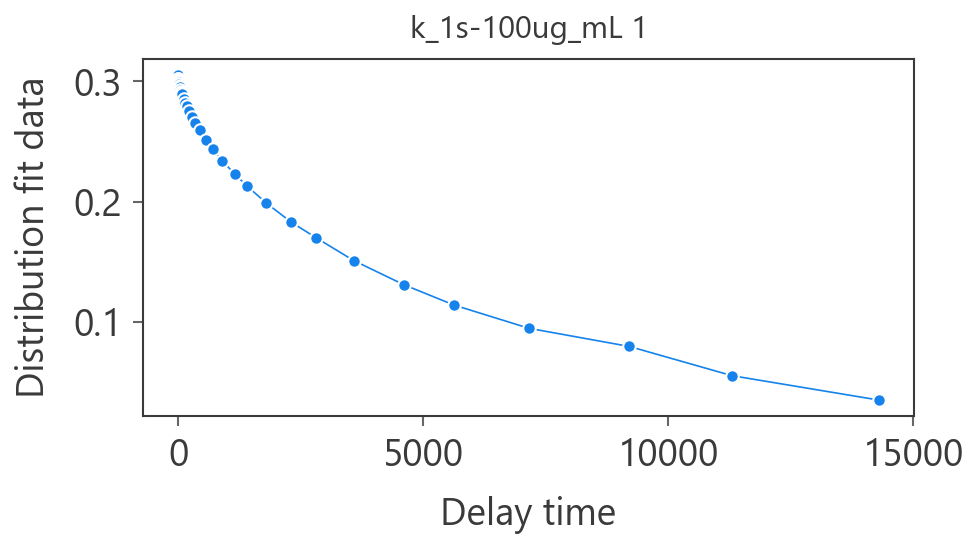

In [75]:
example_sample = df_distribution_long["Sample_Name"].dropna().unique()[0]

tmp = df_distribution_long[df_distribution_long["Sample_Name"] == example_sample]

plt.figure(figsize=(7, 4))
plt.plot(tmp["distribution_delay_time"], tmp["distribution_fit_data"], marker="o")
plt.xlabel("Delay time")
plt.ylabel("Distribution fit data")
plt.title(example_sample)
plt.tight_layout()
plt.show()

## Read `quality.txt`

In [76]:
df_quality = read_simple_zetasizer_file(DATA_RAW_DIR / "quality.txt")
df_quality = df_quality[df_quality["Type"] == "Size"].copy()

print(df_quality.shape)
display(df_quality.head())

(45, 4)


,Measurement_Date_and_Time,Type,Sample_Name,Quality_Factor
0,"sexta-feira, 17 de abril de 2026 14:44:45",Size,k_1s-100ug_mL 1,0.0
1,"sexta-feira, 17 de abril de 2026 14:46:49",Size,k_1s-100ug_mL 2,0.0
2,"sexta-feira, 17 de abril de 2026 14:48:52",Size,k_1s-100ug_mL 3,0.0
3,"sexta-feira, 17 de abril de 2026 14:49:26",Size,k_1s-100ug_mL-mean,0.0
8,"sexta-feira, 17 de abril de 2026 15:12:16",Size,milli_q-water 1,0.0


### Merge quality factor to principal table

In [77]:
df_dls_main = df_dls_main.merge(
    df_quality[["Sample_Name", "Quality_Factor"]],
    on="Sample_Name",
    how="left"
)

display(df_dls_main.head())

,Measurement_Date_and_Time,Sample_Name,sample_base,carrageenan_code,carrageenan,concentration_value,concentration_unit,concentration_label,matrix,replicate,Z_Average_d_nm,PdI,PdI_Width_d_nm,Mean_Count_Rate_kcps,Intercept,Intensity_Mean_d_nm,Size_Peak_d_nm,Size_Peak_By_Size_d_nm,Derived_Count_Rate_kcps,Measured_Intercept,Measured_Size_Baseline,Quality_Factor
0,"sexta-feira, 17 de abril de 2026 14:44:45",k_1s-100ug_mL 1,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,1,1530.0,0.690,1271.0,286.7,0.305,2662.0,2979.0,28.56,1020.2,0.096,0.00373,0.0
1,"sexta-feira, 17 de abril de 2026 14:46:49",k_1s-100ug_mL 2,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,2,1516.0,0.570,1145.0,311.0,0.287,2536.0,2712.0,143.60,1106.9,0.088,0.00572,0.0
2,"sexta-feira, 17 de abril de 2026 14:48:52",k_1s-100ug_mL 3,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,3,1063.0,0.723,903.6,269.7,0.276,2093.0,2253.0,23.76,959.9,0.079,0.00163,0.0
3,"sexta-feira, 17 de abril de 2026 15:12:16",milli_q-water 1,milli_q-water,NaN,NaN,NaN,NaN,NaN,water,1,0.0,0.000,0.0,24.4,0.000,0.0,0.0,0.00,24.4,0.000,0.00000,0.0
4,"sexta-feira, 17 de abril de 2026 15:41:24",k_1s-1mg_mL 1,k_1s-1mg_mL,k,kappa,1.0,mg/mL,1 mg/mL,water,1,1164.0,0.488,813.4,207.0,0.915,939.8,1003.0,50.38,736.7,0.841,0.00510,0.0


## Save initial processed tables

In [78]:
# df_dls_main.to_csv(DATA_PROCESSED_DIR / "dls_main.csv", index=False)
# df_correlations.to_csv(DATA_PROCESSED_DIR / "correlations_wide.csv", index=False)
# df_correlations_long.to_csv(DATA_PROCESSED_DIR / "correlations_long.csv", index=False)
# df_distribution_raw.to_pickle(DATA_PROCESSED_DIR / "distribution_raw.pkl")
# df_distribution_long.to_csv(DATA_PROCESSED_DIR / "distribution_long.csv", index=False)
# df_quality.to_csv(DATA_PROCESSED_DIR / "quality.csv", index=False)

# print("Arquivos salvos em:", DATA_PROCESSED_DIR)

# **Notebook final summary**

In [79]:
print("Notebook 01 Summary")
print("-" * 50)
print("df_dls_main:", df_dls_main.shape)
print("df_correlations:", df_correlations.shape)
print("df_correlations_long:", df_correlations_long.shape)
print("df_distribution_raw:", df_distribution_raw.shape)
print("df_distribution_long:", df_distribution_long.shape)
print("df_quality:", df_quality.shape)

Notebook 01 Summary
--------------------------------------------------
df_dls_main: (34, 22)
df_correlations: (45, 387)
df_correlations_long: (8640, 4)
df_distribution_raw: (45, 9)
df_distribution_long: (1709, 15)
df_quality: (45, 4)


In [80]:
df_dls_main[[
    "Sample_Name",
    "sample_base",
    "carrageenan",
    "concentration_label",
    "matrix",
    "replicate"
]].sort_values(["sample_base", "replicate"])

,Sample_Name,sample_base,carrageenan,concentration_label,matrix,replicate
25,L_3S-1mg_mL 1,L_3S-1mg_mL,lambda,1 mg/mL,water,1
26,L_3S-1mg_mL 2,L_3S-1mg_mL,lambda,1 mg/mL,water,2
27,L_3S-1mg_mL 3,L_3S-1mg_mL,lambda,1 mg/mL,water,3
19,L_3S-35ug_mL 1,L_3S-35ug_mL,lambda,35 ug/mL,water,1
20,L_3S-35ug_mL 2,L_3S-35ug_mL,lambda,35 ug/mL,water,2
21,L_3S-35ug_mL 3,L_3S-35ug_mL,lambda,35 ug/mL,water,3
13,aMEM-Ctrl 1,aMEM-Ctrl,NaN,NaN,medium,1
14,aMEM-Ctrl 2,aMEM-Ctrl,NaN,NaN,medium,2
15,aMEM-Ctrl 3,aMEM-Ctrl,NaN,NaN,medium,3
7,aMEM_10pct-Ctrl 1,aMEM_10pct-Ctrl,NaN,NaN,medium,1
